# 2D non-rigid — WS₂

**After affine.** Automatic `correct_affine()`, then run the accepted
one-knot publication correction once. Saves
`data/ws2/drift.zip` for Figure 4.

## Strategy

1. **Affine first** — non-rigid only polishes residual scanline warp.
2. **Pick a regime** — soft/general (this notebook) vs atomic lattice.
3. **Judge with `plot_combined` + `report()`** — keep the stage only if both
   improve; reject phase hop / zipper even if loss drops.
4. **Lattice caution** — use `max_image_shift=1` or `2` on pure lattices
   (this notebook ships soft/general: `32`).

| Path | Notebook |
|------|----------|
| Automated affine | `2d_affine_co3o4.ipynb` |
| Explicit affine grid | `advanced/2d_affine_explicit_co3o4.ipynb` |
| This non-rigid polish | `2d_nonrigid_ws2.ipynb` |
| Knot sweeps and safety | `advanced/2d_nonrigid_safety_ws2.ipynb` |

Interactive viewing is enabled by default. Set `INTERACTIVE = False` in the
device cell for static/report rendering.


## Environment

Install the reviewed paper API and latest published `quantem.widget` release
candidate. One notebook supports both interactive and static/report output:

```bash
python -m pip install --upgrade \
  "git+https://github.com/bobleesj/quantem.git@drift-paper"
python -m pip install --pre --upgrade \
  --index-url https://test.pypi.org/simple \
  --extra-index-url https://pypi.org/simple quantem.widget
```


## Data

Download the [raw WS₂ data](https://drive.google.com/drive/folders/108vcQW2ycaZ1scKTWJK5jVCNfGZnxaiB?usp=sharing)
and place the files in `data/ws2/`. The shared folder contains only the
original acquisitions; this notebook generates its result locally.


## Device and paths


In [1]:
from pathlib import Path

import quantem.widget as qw
from quantem.imaging import DriftCorrection

# Raw EMDs + AutoSerialized result under DATA (same layout as affine tutorials).
DATA = Path("data/ws2")
RESULT = DATA / "drift.zip"  # Figure 4 loads this zip

# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = True
VIEW_MODE = "interactive" if INTERACTIVE else "static"

qw.profile()


quantem.widget  0.0.1rc37
  install       published package
quantem.gpu     0.0.1rc6
  install       source override (differs from installed metadata)
quantem         0.1.9
torch           2.13.0  device=cuda (NVIDIA RTX PRO 6000)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=0)
  GPU0           25.2 used / 102 GB  (77 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.14.6


## Load

`from_emd` reads scan rotation from Velox metadata — do not hardcode angles.


In [2]:
drift = DriftCorrection.from_emd(
    DATA / "0127_VWS2_9h_g_300kv_STEM_HAADF_5.20_Mx_Diffraction.emd",
    DATA / "0128_VWS2_9h_g_300kv_STEM_HAADF_5.20_Mx_Diffraction.emd",
    verbose=False,
)


## Affine first (automatic)

Same quiet automatic call as the Co₃O₄ template. Get a solid affine before any
non-rigid polish. For an explicit grid, see the matching
`advanced/2d_affine_explicit_*.ipynb`.


In [3]:
drift.correct_affine(
    show_combined=False,  # RGB during solve (inspection cells preferred)
    show_scans=False,     # each warped scan
    verbose=False,        # candidate progress
)


## Check affine — `plot_combined`

Confirm yellow registration before spending time on non-rigid. If affine is
bad, fix affine — do not “rescue” with non-rigid.


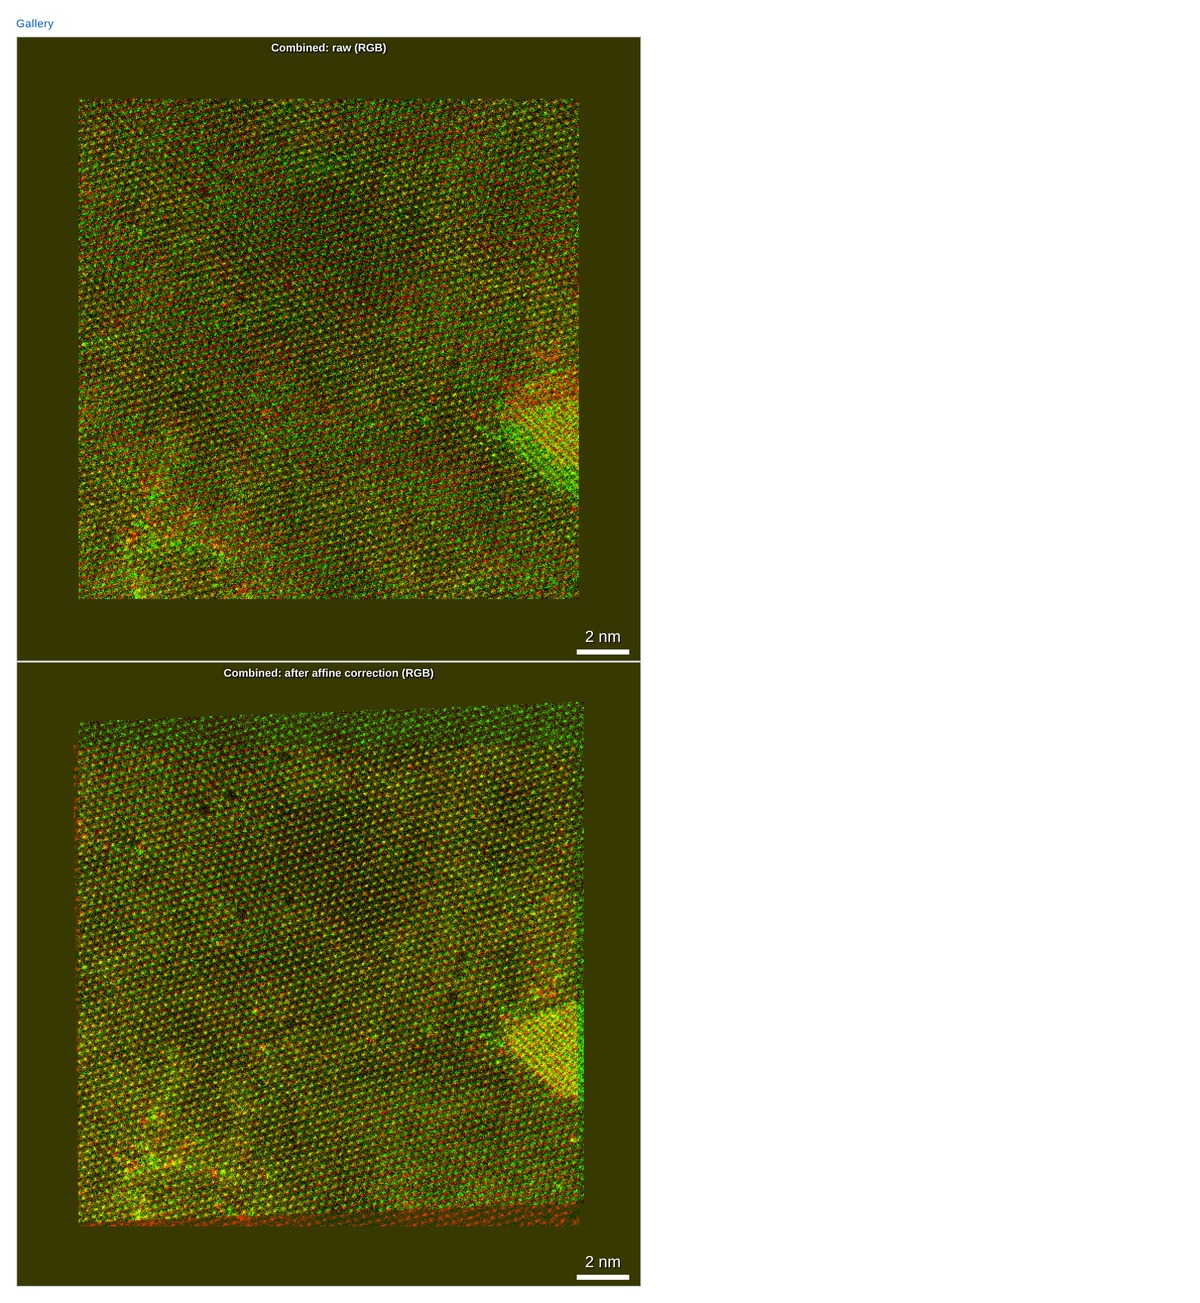

In [4]:
drift.plot_combined(
    stage=("initial", "affine"),  # before | after affine
    interactive=INTERACTIVE,       # linked widget | static Matplotlib
    width=620,                    # panel width px — 400 | 620 | 900
    # show_fft=False,             # FFT under each panel
    # zoom=1.0,
    # center=(0.0, 0.0),          # fractional (row, col) in [-0.5, 0.5]
)


## Non-rigid correction

The publication endpoint uses one knot per scanline. This default tutorial
runs that accepted endpoint once. Candidate sweeps and failure-mode diagnosis
belong in `advanced/2d_nonrigid_safety_ws2.ipynb`.

### Why these publication settings?

**Soft / general regime (this cell)** — WS₂ publication / Figure 4. Broad
`max_image_shift` is OK on non-periodic structure.

**Atomic lattice regime** — change only these first, then re-judge:

```python
max_image_shift=2,       # was 32; tiny = avoid lattice alias
knot_smoothing_sigma=16, # stiffer rows (try 8–16)
```

If residual after affine is a **smooth slow-scan bend** (common in EDS
reference mode), try `drift.correct_strip(...)` before free non-rigid.

The full publication recipe remains visible in the cell below.


In [5]:
drift.correct_nonrigid(
    num_knots=1,
    optimizer="adam",
    num_refine_cycles=128,
    optimizer_steps=30,
    learning_rate=0.1,
    knot_smoothing_sigma=8.0,
    update_fraction=0.8,
    trend_order=1,
    max_image_shift=32,
    loss="mse",
    early_stop_patience=128,
    min_iterations=4,
    show_combined=False,
    show_scans=False,
    show_knots=False,
    verbose=True,
)


Solving nonrigid drift (adam):   0%|          | 0/128 [00:00<?, ?it/s]

Solving nonrigid drift (adam):   0%|          | 0/128 [00:00<?, ?it/s, error=0.01542, best=0.01542]

Solving nonrigid drift (adam):   1%|          | 1/128 [00:00<01:34,  1.34it/s, error=0.01542, best=0.01542]

Solving nonrigid drift (adam):   1%|          | 1/128 [00:00<01:34,  1.34it/s, error=0.01535, best=0.01535]

Solving nonrigid drift (adam):   1%|          | 1/128 [00:00<01:34,  1.34it/s, error=0.01533, best=0.01533]

...

Solving nonrigid drift (adam):  96%|█████████▌| 123/128 [00:05<00:00, 29.01it/s, error=0.01406, best=0.01406]

Solving nonrigid drift (adam):  98%|█████████▊| 126/128 [00:05<00:00, 29.07it/s, error=0.01406, best=0.01406]

Solving nonrigid drift (adam):  98%|█████████▊| 126/128 [00:05<00:00, 29.07it/s, error=0.01406, best=0.01406]

Solving nonrigid drift (adam):  98%|█████████▊| 126/128 [00:05<00:00, 29.07it/s, error=0.01406, best=0.01406]

Solving nonrigid drift (adam): 100%|██████████| 128/128 [00:05<00:00, 21.75it/s, error=0.01406, best=0.01406]

## Check non-rigid — `plot_combined`

Three stages side by side. Look for yellow tighten vs affine **without**
lattice hop or zipper. Then read scores.


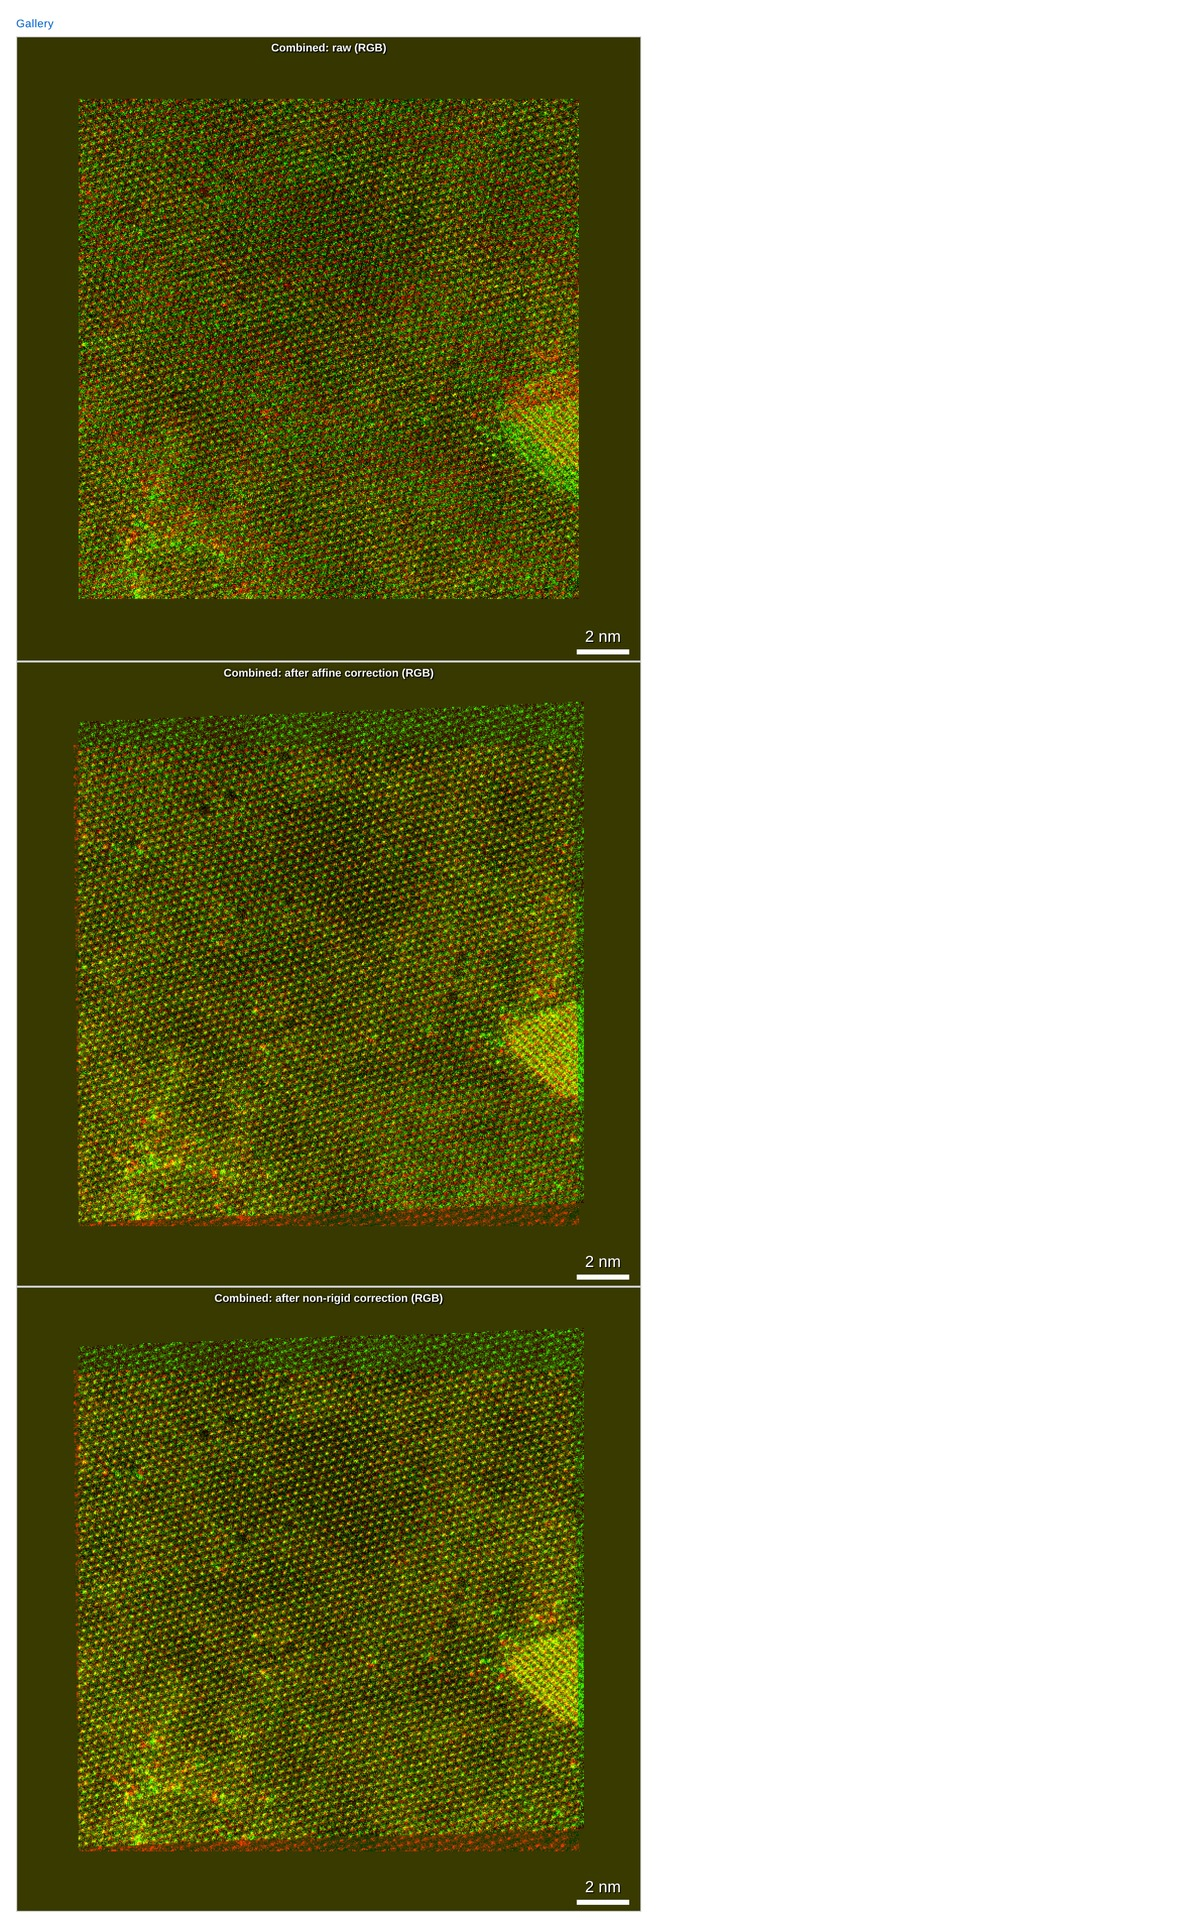

In [6]:
drift.plot_combined(
    stage=("initial", "affine", "nonrigid"),
    interactive=INTERACTIVE,       # linked widget | static Matplotlib
    width=620,
    # show_fft=False,
    # zoom=1.0,
    # center=(0.0, 0.0),
)


## Scores — `report()`

Regional NCC on the common-coverage mask across stages. Non-rigid should not
hurt affine regional scores on a good run.


In [7]:
drift.report()


,Common NCC,Top third,Middle third,Bottom third,Coverage
Mutual stage,,,,,
before,0.066186,0.021736,0.068713,0.073954,0.928148
affine,0.248166,0.219933,0.276240,0.213764,0.928148
nonrigid,0.405744,0.386155,0.419564,0.382956,0.928148


## Corrected result — `show()`

Grayscale product gallery (not the RGB registration check). Display-only knobs.


  Display bin 3×: 2560×2560 → 853×853 (16 MB preview; full-res detail streams on zoom)


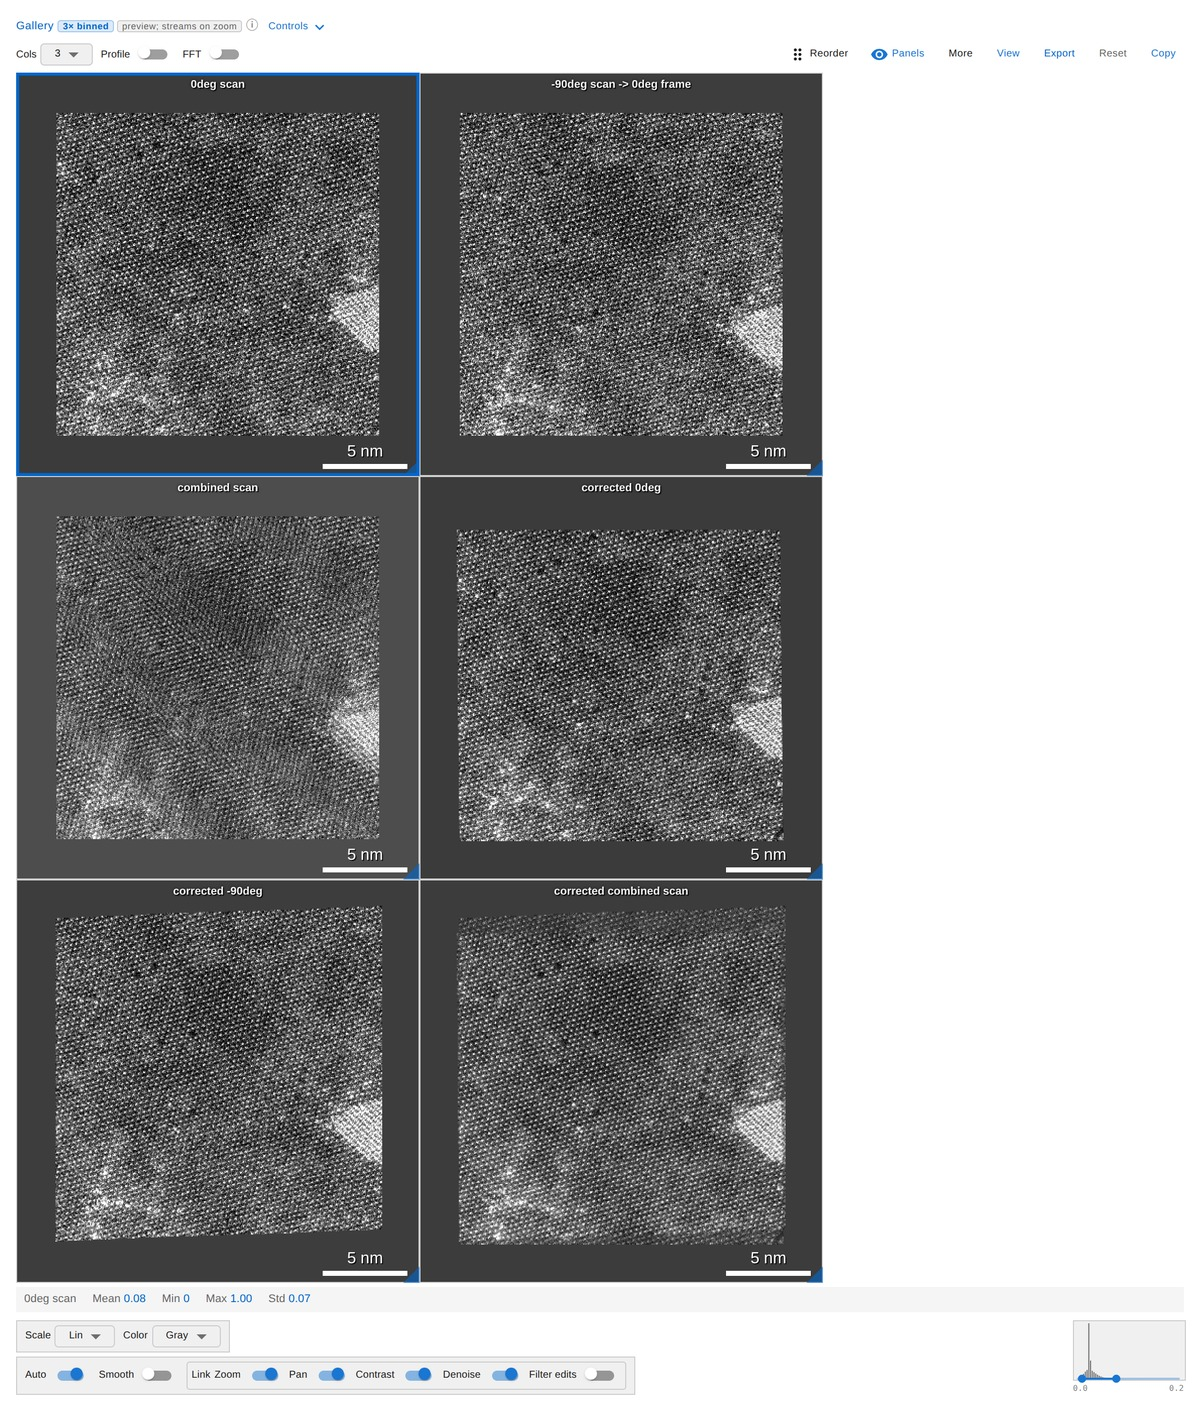

In [8]:
drift.show(
    mode=VIEW_MODE,
    cmap="gray",           # gray | inferno | viridis | plasma
    auto_contrast=True,    # percentile clim | full range
    link_contrast=True,    # shared clim across panels
    smooth=False,          # nearest | interpolated
    show_fft=False,        # FFT companion panels
    # zoom=1.0,
    # size=400,
    # center=(0.0, 0.0),
)


## Save

AutoSerialize next to the EMDs. Figure notebooks load this zip — they do not
re-run correction.


In [9]:
DATA.mkdir(parents=True, exist_ok=True)
drift.save(RESULT, mode="o")
print(f"Saved: {RESULT}")


Saved: data/ws2/drift.zip


## Next steps

- **Your pair:** change `DATA` and the two EMD names; start soft, then try
  lattice-safe `max_image_shift` if columns look periodic.
- **Affine only:** `2d_affine_co3o4.ipynb`
- **Explicit affine:** the matching `advanced/2d_affine_explicit_*.ipynb`
- **Non-rigid safety checks:** `advanced/2d_nonrigid_safety_ws2.ipynb`
- **WS₂ affine diagnostics:** `advanced/2d_affine_diagnostics_ws2_0070_0071.ipynb`
- **Smooth residual / EDS:** prefer `correct_strip` before free non-rigid

Regenerate this notebook:

```bash
python tutorials/template/build_2d_nonrigid_tutorial.py
```
